# Visualize Shape Complexity and Symmetry Scores

This notebook visualizes the CSV outputs from `scripts/run_shape_complexity_symmetry.py`.

The complexity plots answer: how does reconstruction complexity change with developmental time and organoid size?

The symmetry plots are intentionally not hard-label plots only. Early organoids can be close to spherical, so several symmetry classes and axes may all score well. The useful question during development is often: which symmetry candidates remain strong as shapes become more complex?

In [150]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

plt.style.use("default")


## Load Results

`summary_df` has one row per organoid. `symmetry_df` has one row per organoid, symmetry group, and tested axis. With the default script settings, each organoid should have 9 symmetry rows: 3 symmetry groups x 3 PCA axes.

You can load multiple datasets by editing `DATASETS`. Timepoints are also grouped into `timepoint_group`: suffixes after a hyphen are ignored, so `day4p5-more` is grouped with `day4p5`. The original timepoint remains in the `timepoint` column.


In [151]:
NOTEBOOK_DIR = Path.cwd().resolve()
DATASETS = ["20250929", "20251201"]

summary_frames = []
symmetry_frames = []
missing_outputs = []

for dataset in DATASETS:
    result_dir = NOTEBOOK_DIR / ".." / ".." / "NicoleData" / dataset / "shape_complexity_symmetry"
    summary_csv = result_dir / "shape_complexity_symmetry_summary.csv"
    symmetry_csv = result_dir / "shape_complexity_symmetry_symmetry_long.csv"

    if not summary_csv.exists() or not symmetry_csv.exists():
        missing_outputs.append((dataset, summary_csv, symmetry_csv))
        continue

    summary_part = pd.read_csv(summary_csv)
    symmetry_part = pd.read_csv(symmetry_csv)

    # Make dataset explicit even if older CSVs did not store it.
    summary_part["dataset"] = dataset
    symmetry_part["dataset"] = dataset

    summary_frames.append(summary_part)
    symmetry_frames.append(symmetry_part)

if not summary_frames:
    missing_text = "\n".join(
        f"{dataset}: {summary_csv} / {symmetry_csv}"
        for dataset, summary_csv, symmetry_csv in missing_outputs
    )
    raise FileNotFoundError(
        "No shape-complexity/symmetry CSV outputs found. "
        "Run scripts/run_shape_complexity_symmetry.py first.\n"
        + missing_text
    )

summary_df = pd.concat(summary_frames, ignore_index=True)
symmetry_df = pd.concat(symmetry_frames, ignore_index=True)

# In the long table this column names the tested axis, not only the winner.
symmetry_df = symmetry_df.rename(columns={"best_axis": "axis"})

def canonical_timepoint(tp):
    # Group day4p5-more with day4p5, while keeping the original in `timepoint`.
    return str(tp).split("-", 1)[0]

def timepoint_key(tp):
    text = str(tp)
    match = re.search(r"(\d+(?:p\d+)?)", text)
    if match:
        return float(match.group(1).replace("p", "."))
    return np.inf

summary_df["timepoint_group"] = summary_df["timepoint"].map(canonical_timepoint)
symmetry_df["timepoint_group"] = symmetry_df["timepoint"].map(canonical_timepoint)

summary_df["sample_key"] = summary_df["dataset"].astype(str) + "::" + summary_df["label_uid"].astype(str)
symmetry_df["sample_key"] = symmetry_df["dataset"].astype(str) + "::" + symmetry_df["organoid_id"].astype(str)

timepoint_order = sorted(summary_df["timepoint_group"].dropna().unique(), key=timepoint_key)
summary_df["timepoint_group"] = pd.Categorical(summary_df["timepoint_group"], categories=timepoint_order, ordered=True)
symmetry_df["timepoint_group"] = pd.Categorical(symmetry_df["timepoint_group"], categories=timepoint_order, ordered=True)

print(f"datasets     : {DATASETS}")
print(f"summary rows : {len(summary_df)}")
print(f"symmetry rows: {len(symmetry_df)}")
print("time groups  :", list(timepoint_order))
if missing_outputs:
    print("missing outputs skipped:")
    for dataset, summary_csv, symmetry_csv in missing_outputs:
        print(f"  {dataset}: {summary_csv} / {symmetry_csv}")

display(summary_df.head())
display(symmetry_df.head())


datasets     : ['20250929', '20251201']
summary rows : 3040
symmetry rows: 27360
time groups  : ['day1p5', 'day2', 'day2p5', 'day3', 'day3p5', 'day4', 'day4p5']


,dataset,timepoint,well,organoid_id,label_uid,mesh_path,n_cells,n_vertices,n_faces,raw_volume,...,symmetry_C3_best_axis,symmetry_C3_axis_x,symmetry_C3_axis_y,symmetry_C3_axis_z,symmetry_C3_trimmed_rms,symmetry_C3_normalized_rms,symmetry_C3_median,symmetry_C3_matched_fraction,timepoint_group,sample_key
0,20250929,day1p5,A01,1,day1p5_A01_1,/home/fmoller/Projects/LearningOrganoids/Nicol...,4,51688,103372,5047.901367,...,PCA3,0.018234,0.147771,0.988854,0.052506,0.057305,0.045848,0.550813,day1p5,20250929::day1p5_A01_1
1,20250929,day1p5,A01,102,day1p5_A01_102,/home/fmoller/Projects/LearningOrganoids/Nicol...,8,18001,35998,8629.406250,...,PCA3,-0.013347,-0.225071,0.974251,0.033470,0.035814,0.031224,0.866187,day1p5,20250929::day1p5_A01_102
2,20250929,day1p5,A01,103,day1p5_A01_103,/home/fmoller/Projects/LearningOrganoids/Nicol...,6,18001,35998,7409.714844,...,PCA3,0.035133,-0.243365,0.969298,0.048261,0.051664,0.038904,0.637938,day1p5,20250929::day1p5_A01_103
3,20250929,day1p5,A01,104,day1p5_A01_104,/home/fmoller/Projects/LearningOrganoids/Nicol...,4,55989,111974,5821.813965,...,PCA3,0.176933,0.149391,0.972819,0.052553,0.057195,0.047543,0.533500,day1p5,20250929::day1p5_A01_104
4,20250929,day1p5,A01,109,day1p5_A01_109,/home/fmoller/Projects/LearningOrganoids/Nicol...,8,18001,35998,6946.073242,...,PCA3,-0.252579,-0.422173,0.870617,0.028810,0.032288,0.026713,0.926562,day1p5,20250929::day1p5_A01_109


,organoid_id,l,n_modes,symmetry,axis,candidate_source,axis_x,axis_y,axis_z,trimmed_rms,...,n_samples,characteristic_scale,close_threshold,dataset,timepoint,well,organoid_id_raw,mesh_path,timepoint_group,sample_key
0,day1p5_A01_1,8,64,reflection,PCA1,PCA,0.816129,0.569134,-0.100099,0.045143,...,8000,1.070288,0.05,20250929,day1p5,A01,1,/home/fmoller/Projects/LearningOrganoids/Nicol...,day1p5,20250929::day1p5_A01_1
1,day1p5_A01_1,8,64,reflection,PCA2,PCA,-0.577582,0.808857,-0.110222,0.052771,...,8000,1.070288,0.05,20250929,day1p5,A01,1,/home/fmoller/Projects/LearningOrganoids/Nicol...,day1p5,20250929::day1p5_A01_1
2,day1p5_A01_1,8,64,reflection,PCA3,PCA,0.018234,0.147771,0.988854,0.046110,...,8000,1.070288,0.05,20250929,day1p5,A01,1,/home/fmoller/Projects/LearningOrganoids/Nicol...,day1p5,20250929::day1p5_A01_1
3,day1p5_A01_1,8,64,C2,PCA1,PCA,0.816129,0.569134,-0.100099,0.050466,...,8000,1.070288,0.05,20250929,day1p5,A01,1,/home/fmoller/Projects/LearningOrganoids/Nicol...,day1p5,20250929::day1p5_A01_1
4,day1p5_A01_1,8,64,C2,PCA2,PCA,-0.577582,0.808857,-0.110222,0.043065,...,8000,1.070288,0.05,20250929,day1p5,A01,1,/home/fmoller/Projects/LearningOrganoids/Nicol...,day1p5,20250929::day1p5_A01_1


## Complexity Over Time

`complexity_error_at_l` is the area-weighted relative reconstruction error at the chosen analysis level. Higher values mean that this number of modes reconstructs the organoid less well, which usually means a more complex coarse shape.

`complexity_error_auc` summarizes the reconstruction-error curve across `COMPLEXITY_L_VALUES`. Higher values mean reconstruction error remains high over more spectral levels.

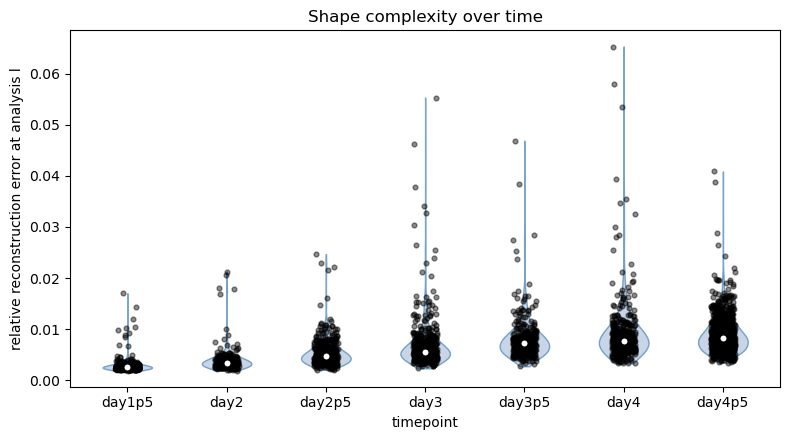

In [152]:
complexity_metric = "complexity_error_at_l"

time_col = "timepoint_group"
fig, ax = plt.subplots(figsize=(8, 4.5))
positions = np.arange(1, len(timepoint_order) + 1)
data_by_time = [
    summary_df.loc[summary_df[time_col] == tp, complexity_metric].dropna().to_numpy()
    for tp in timepoint_order
]

parts = ax.violinplot(data_by_time, positions=positions, showmeans=False, showmedians=False, showextrema=False)
for body in parts["bodies"]:
    body.set_facecolor("lightsteelblue")
    body.set_edgecolor("steelblue")
    body.set_alpha(0.7)

rng = np.random.default_rng(0)
for pos, values in zip(positions, data_by_time):
    if values.size == 0:
        continue
    q1, median, q3 = np.percentile(values, [25, 50, 75])
    ax.vlines(pos, q1, q3, color="black", linewidth=2)
    ax.scatter(pos, median, color="white", edgecolor="black", zorder=3, s=28)
    jitter = rng.uniform(-0.12, 0.12, size=values.size)
    ax.scatter(pos + jitter, values, color="black", s=12, alpha=0.45, zorder=2)

ax.set_xticks(positions)
ax.set_xticklabels(timepoint_order)
ax.set_xlabel("timepoint")
ax.set_ylabel("relative reconstruction error at analysis l")
ax.set_title("Shape complexity over time")
fig.tight_layout()


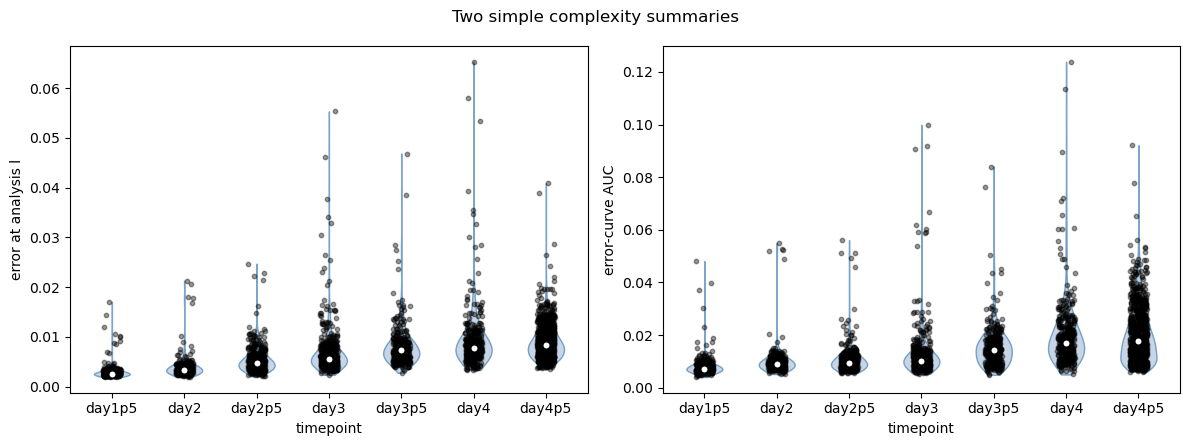

In [153]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=True)
rng = np.random.default_rng(1)
positions = np.arange(1, len(timepoint_order) + 1)
time_col = "timepoint_group"

for ax, metric, label in [
    (axes[0], "complexity_error_at_l", "error at analysis l"),
    (axes[1], "complexity_error_auc", "error-curve AUC"),
]:
    data_by_time = [
        summary_df.loc[summary_df[time_col] == tp, metric].dropna().to_numpy()
        for tp in timepoint_order
    ]
    parts = ax.violinplot(data_by_time, positions=positions, showmeans=False, showmedians=False, showextrema=False)
    for body in parts["bodies"]:
        body.set_facecolor("lightsteelblue")
        body.set_edgecolor("steelblue")
        body.set_alpha(0.7)

    for pos, values in zip(positions, data_by_time):
        if values.size == 0:
            continue
        q1, median, q3 = np.percentile(values, [25, 50, 75])
        ax.vlines(pos, q1, q3, color="black", linewidth=2)
        ax.scatter(pos, median, color="white", edgecolor="black", zorder=3, s=28)
        jitter = rng.uniform(-0.12, 0.12, size=values.size)
        ax.scatter(pos + jitter, values, color="black", s=10, alpha=0.4, zorder=2)

    ax.set_xticks(positions)
    ax.set_xticklabels(timepoint_order)
    ax.set_xlabel("timepoint")
    ax.set_ylabel(label)

fig.suptitle("Two simple complexity summaries")
fig.tight_layout()


## Complexity Versus Cell Count

This plot treats cell count as a developmental timescale. Hover over points to inspect individual organoids.

In [154]:
fig = px.scatter(
    summary_df,
    x="n_cells",
    y="complexity_error_at_l",
    color="timepoint_group",
    symbol="dataset",
    hover_data=["dataset", "timepoint", "label_uid", "well", "organoid_id", "raw_volume", "raw_surface_area"],
    labels={
        "n_cells": "number of cells",
        "complexity_error_at_l": "relative reconstruction error at analysis l",
        "timepoint_group": "timepoint",
    },
    title="Shape complexity versus organoid cell count",
)
fig.update_traces(marker=dict(size=7, opacity=0.75))
fig.show()


## Symmetry Visualization Strategy

For symmetry, I would not start with a winner-takes-all label. Early nearly spherical organoids may score well for many axes and many symmetry classes. A useful progression is:

1. Plot all candidate scores over time to see whether symmetry strength globally decays.
2. Define a practical survival threshold, then plot the fraction of candidate axes that survive per symmetry class.
3. Plot survival against a developmental timescale such as cell count or complexity, because shape state may be more informative than nominal timepoint.
4. Only after that, inspect the best surviving class per organoid if you need a compact label.

Below, `matched_fraction` is used because it reads naturally as “how much of the surface is explained.” You can switch to `trimmed_rms`; lower is better for RMS metrics.

In [155]:
symmetry_metric = "matched_fraction"
survival_thresholds = [0.25, 0.5]

symmetry_plot_df = symmetry_df.copy()

def symmetry_survival_table(df, group_cols):
    tables = []
    for threshold in survival_thresholds:
        table = (
            df.assign(survives=df[symmetry_metric] >= threshold)
            .groupby(group_cols, observed=True)["survives"]
            .mean()
            .reset_index(name="survival_fraction")
        )
        table["survival_threshold"] = threshold
        table["threshold_label"] = f">= {threshold:.1f}"
        tables.append(table)
    return pd.concat(tables, ignore_index=True)

print(f"Survival thresholds: {symmetry_metric} >= {survival_thresholds}")

Survival thresholds: matched_fraction >= [0.25, 0.5]


### Sphere-Like Versus Non-Sphere-Like Organoids

Early organoids can be close enough to spherical that axis-specific symmetry labels become ambiguous. This cell assigns a coarse `sphere_like_group` so the symmetry plots can be interpreted separately for sphere-like and non-sphere-like shapes.

By default, sphere-likeness is based on surface-area/volume sphericity: a perfect sphere has sphericity 1, and more elongated or folded shapes have lower values. You can switch to a complexity-based rule by changing `SPHERE_LIKE_METHOD`.

In [ ]:
SPHERE_LIKE_METHOD = "sphericity"  # "sphericity" or "complexity"
SPHERICITY_THRESHOLD = 0.925
COMPLEXITY_SPHERE_THRESHOLD = None  # None uses the lower third of complexity_error_at_l

volume = summary_df["raw_volume"].abs().astype(float)
area = summary_df["raw_surface_area"].astype(float)
summary_df["sphericity"] = np.where(
    area > 0,
    (np.pi ** (1.0 / 3.0)) * ((6.0 * volume) ** (2.0 / 3.0)) / area,
    np.nan,
)

if SPHERE_LIKE_METHOD == "sphericity":
    summary_df["sphere_like"] = summary_df["sphericity"] >= SPHERICITY_THRESHOLD
    sphere_rule = f"sphericity >= {SPHERICITY_THRESHOLD}"
elif SPHERE_LIKE_METHOD == "complexity":
    threshold = COMPLEXITY_SPHERE_THRESHOLD
    if threshold is None:
        threshold = float(summary_df["complexity_error_at_l"].quantile(1.0 / 3.0))
    summary_df["sphere_like"] = summary_df["complexity_error_at_l"] <= threshold
    sphere_rule = f"complexity_error_at_l <= {threshold:.3f}"
else:
    raise ValueError("SPHERE_LIKE_METHOD must be 'sphericity' or 'complexity'")

summary_df["sphere_like_group"] = np.where(summary_df["sphere_like"], "sphere-like", "non-sphere-like")
sphere_order = ["sphere-like", "non-sphere-like"]

def ensure_sample_key(df, id_candidates):
    if "sample_key" in df.columns:
        return df["sample_key"]
    id_col = next((col for col in id_candidates if col in df.columns), None)
    if id_col is None:
        raise KeyError(f"Could not build sample_key; expected one of {id_candidates}")
    if "dataset" in df.columns:
        return df["dataset"].astype(str) + "::" + df[id_col].astype(str)
    return df[id_col].astype(str)

summary_df["sample_key"] = ensure_sample_key(summary_df, ["label_uid", "organoid_id"])
symmetry_plot_df["sample_key"] = ensure_sample_key(symmetry_plot_df, ["organoid_id", "label_uid"])

sphere_cols = ["sample_key", "sphericity", "sphere_like", "sphere_like_group"]
sphere_annotation_cols = ["sphericity", "sphere_like", "sphere_like_group"]
symmetry_plot_df = symmetry_plot_df.drop(columns=[col for col in sphere_annotation_cols if col in symmetry_plot_df.columns], errors="ignore")
symmetry_plot_df = symmetry_plot_df.merge(summary_df[sphere_cols], on="sample_key", how="left")
symmetry_plot_df["sphere_like_group"] = pd.Categorical(symmetry_plot_df["sphere_like_group"], categories=sphere_order, ordered=True)

print(f"Sphere-like rule: {sphere_rule}")
display(
    summary_df
    .groupby(["timepoint_group", "sphere_like_group"], observed=True)
    .size()
    .reset_index(name="n_organoids")
)

Sphere-like rule: sphericity >= 0.9


,timepoint_group,sphere_like_group,n_organoids
0,day1p5,non-sphere-like,3
1,day1p5,sphere-like,377
2,day2,non-sphere-like,5
3,day2,sphere-like,275
4,day2p5,non-sphere-like,4
5,day2p5,sphere-like,366
6,day3,non-sphere-like,17
7,day3,sphere-like,455
8,day3p5,non-sphere-like,18
9,day3p5,sphere-like,294


### Symmetry Scores Split By Sphere-Likeness

These plots repeat the symmetry score view but separate sphere-like and non-sphere-like organoids. This helps avoid over-interpreting axis-specific C2/C3 behavior in nearly spherical shapes.

In [157]:
fig = px.box(
    symmetry_plot_df,
    x="timepoint_group",
    y=symmetry_metric,
    color="axis",
    facet_col="symmetry",
    facet_row="sphere_like_group",
    points=False,
    category_orders={
        "timepoint_group": timepoint_order,
        "symmetry": ["reflection", "C2", "C3"],
        "sphere_like_group": sphere_order,
    },
    labels={"timepoint_group": "timepoint", symmetry_metric: "matched fraction"},
    title="Symmetry candidates over time, split by sphere-likeness",
)
for threshold in survival_thresholds:
    fig.add_hline(y=threshold, line_dash="dash", line_color="black", annotation_text=f"{threshold:.1f}")
fig.update_traces(boxmean=False)
fig.update_yaxes(range=[-0.02, 1.02])
fig.update_layout(height=650)
fig.show()

### Symmetry Survival Split By Sphere-Likeness

Here the survival fraction is computed separately within sphere-like and non-sphere-like organoids. This is often the clearest way to see whether a specific symmetry class persists after the roughly spherical stage.

In [158]:
survival_by_time_sphere = symmetry_survival_table(
    symmetry_plot_df,
    ["timepoint_group", "sphere_like_group", "symmetry"],
)

fig = px.line(
    survival_by_time_sphere,
    x="timepoint_group",
    y="survival_fraction",
    color="symmetry",
    line_dash="threshold_label",
    facet_row="sphere_like_group",
    markers=True,
    category_orders={"timepoint_group": timepoint_order, "sphere_like_group": sphere_order},
    labels={"timepoint_group": "timepoint", "survival_fraction": "fraction surviving", "threshold_label": "threshold"},
    title="Symmetry survival over time, split by sphere-likeness",
)
fig.update_yaxes(range=[-0.05, 1.05])
fig.update_layout(height=620)
fig.show()

### All Candidate Symmetry Scores Over Time

Each organoid contributes one point for each tested axis. If early organoids are sphere-like, you should see high scores across many symmetry classes and axes.

In [159]:
fig = px.box(
    symmetry_plot_df,
    x="timepoint_group",
    y=symmetry_metric,
    color="axis",
    facet_col="symmetry",
    points=False,
    category_orders={"timepoint_group": timepoint_order, "symmetry": ["reflection", "C2", "C3"]},
    labels={"timepoint_group": "timepoint", symmetry_metric: "matched fraction"},
    title="All tested symmetry candidates over time",
)
for threshold in survival_thresholds:
    fig.add_hline(y=threshold, line_dash="dash", line_color="black", annotation_text=f"{threshold:.1f}")
fig.update_traces(boxmean=False)
fig.update_yaxes(range=[-0.02, 1.02])
fig.show()


### Symmetry Survival Fraction Over Time

This converts the score into an interpretable survival view: for each timepoint, symmetry class, and axis, what fraction of organoids still pass the practical threshold?

In [160]:
survival_by_time = symmetry_survival_table(
    symmetry_plot_df,
    ["timepoint_group", "symmetry", "axis"],
)

fig = px.line(
    survival_by_time,
    x="timepoint_group",
    y="survival_fraction",
    color="axis",
    line_dash="threshold_label",
    facet_col="symmetry",
    markers=True,
    category_orders={"timepoint_group": timepoint_order, "symmetry": ["reflection", "C2", "C3"]},
    labels={"timepoint_group": "timepoint", "survival_fraction": "fraction surviving", "threshold_label": "threshold"},
    title="Which symmetry candidates survive over time?",
)
fig.update_yaxes(range=[-0.05, 1.05])
fig.show()


### Symmetry Survival Along Cell Count or Complexity

The next plots use binned cell count and binned complexity as developmental timescales. This can reveal whether symmetries disappear gradually as organoids become larger or more geometrically complex.

In [161]:
merged_symmetry = symmetry_plot_df.merge(
    summary_df[["sample_key", "n_cells", "complexity_error_at_l"]],
    on="sample_key",
    how="left",
)

n_bins = 5
merged_symmetry["cell_count_bin"] = pd.qcut(
    merged_symmetry["n_cells"],
    q=min(n_bins, merged_symmetry["n_cells"].nunique()),
    duplicates="drop",
)
merged_symmetry["complexity_bin"] = pd.qcut(
    merged_symmetry["complexity_error_at_l"],
    q=min(n_bins, merged_symmetry["complexity_error_at_l"].nunique()),
    duplicates="drop",
)

def bin_midpoint(interval):
    return 0.5 * (interval.left + interval.right)

for col in ["cell_count_bin", "complexity_bin"]:
    merged_symmetry[f"{col}_mid"] = merged_symmetry[col].map(bin_midpoint).astype(float)


In [162]:
survival_by_cells = symmetry_survival_table(
    merged_symmetry,
    ["cell_count_bin_mid", "symmetry"],
)

fig = px.line(
    survival_by_cells,
    x="cell_count_bin_mid",
    y="survival_fraction",
    color="symmetry",
    line_dash="threshold_label",
    markers=True,
    labels={
        "cell_count_bin_mid": "cell count bin midpoint",
        "survival_fraction": "fraction surviving",
        "threshold_label": "threshold",
    },
    title="Symmetry survival versus cell count",
)
fig.update_yaxes(range=[-0.05, 1.05])
fig.show()

In [163]:
survival_by_complexity = symmetry_survival_table(
    merged_symmetry,
    ["complexity_bin_mid", "symmetry"],
)

fig = px.line(
    survival_by_complexity,
    x="complexity_bin_mid",
    y="survival_fraction",
    color="symmetry",
    line_dash="threshold_label",
    markers=True,
    labels={
        "complexity_bin_mid": "complexity bin midpoint",
        "survival_fraction": "fraction surviving",
        "threshold_label": "threshold",
    },
    title="Symmetry survival versus shape complexity",
)
fig.update_yaxes(range=[-0.05, 1.05])
fig.show()

### Best Symmetry Class Per Organoid

This is the most compact view, but it discards useful ambiguity. Use it after looking at the survival plots. For each organoid, we first keep the best axis within each symmetry class, then select the class with the highest matched fraction.

In [164]:
best_axis_per_class = (
    symmetry_plot_df
    .sort_values(symmetry_metric, ascending=False)
    .groupby(["sample_key", "symmetry"], observed=True)
    .head(1)
)
best_class = (
    best_axis_per_class
    .sort_values(symmetry_metric, ascending=False)
    .groupby("sample_key", observed=True)
    .head(1)
)

class_counts = (
    best_class
    .groupby(["timepoint_group", "symmetry"], observed=True)
    .size()
    .reset_index(name="n")
)
class_counts["fraction"] = class_counts["n"] / class_counts.groupby("timepoint_group", observed=True)["n"].transform("sum")

fig = px.bar(
    class_counts,
    x="timepoint_group",
    y="fraction",
    color="symmetry",
    category_orders={"timepoint_group": timepoint_order},
    title="Best symmetry class per organoid",
    labels={"timepoint_group": "timepoint", "fraction": "fraction of organoids"},
)
fig.update_yaxes(range=[0, 1])
fig.show()


### Cell Composition Of Day4p5 Shape Groups

This final section compares cell composition for three `day4p5` groups:

1. sphere-like organoids;
2. non-sphere-like organoids whose best reflection score is at least 0.5;
3. non-sphere-like organoids whose best reflection score is below 0.5.

The cell table is loaded in the same spirit as `scripts/run_graph_preprocess.py`: marker columns come from `cell_table_config.json`, marker exclusivity is enforced first, and proliferation markers are harmonized into `TA`. The bar chart uses fractions so groups with different numbers of organoids can be compared directly.



In [165]:
import sys

PROJECT_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "src").exists() else NOTEBOOK_DIR.parent
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

from organograph.io_utils.dataset_config import load_cell_table_config
from organograph.io_utils.cells_table import (
    enforce_marker_exclusivity,
    harmonize_markers,
    prepare_cells_table,
)

DAY4P5_GROUP = "day4p5"
REFLECTION_COMPOSITION_THRESHOLD = 0.6
CELL_TABLE_CANDIDATES = ["cell_features_class.csv", "cell_types_class.csv"]

EXCLUSIVITY_RULES = {
    "LGR5":     ["Chroma", "Mucin 2", "AldoB", "Glucagon", "Agr2", "Serotonin", "Lysozyme"],
    "Chroma":   ["Mucin 2", "Glucagon", "Serotonin", "Lysozyme"],
    "Mucin 2":  ["Chroma", "Glucagon", "Serotonin", "Lysozyme"],
    "AldoB":    ["Chroma", "Mucin 2", "Glucagon", "Agr2", "Serotonin", "Lysozyme"],
    "Glucagon": ["Serotonin"],
    "Agr2":     ["Chroma", "Mucin 2", "Glucagon", "Serotonin", "Lysozyme"],
    "Serotonin": [],
    "Lysozyme": ["Chroma", "Glucagon", "Serotonin"],
    "Cyclin D": ["LGR5", "Chroma", "Mucin 2", "AldoB", "Glucagon", "Agr2", "Serotonin", "Lysozyme"],
    "Cyclin A": ["LGR5", "Chroma", "Mucin 2", "AldoB", "Glucagon", "Agr2", "Serotonin", "Lysozyme"],
    "KI67":     ["LGR5", "Chroma", "Mucin 2", "AldoB", "Glucagon", "Agr2", "Serotonin", "Lysozyme"],
}

HARMONIZATION_RULES = {
    "TA": ["Cyclin A", "Cyclin D", "KI67"],
}

if "sphere_like_group" not in summary_df.columns:
    raise RuntimeError("Run the sphere-like classification cell before this cell.")

reflection_best = (
    symmetry_plot_df[symmetry_plot_df["symmetry"].eq("reflection")]
    .groupby("sample_key", observed=True)[symmetry_metric]
    .max()
    .rename("best_reflection_score")
)

day4p5_shapes = summary_df[summary_df["timepoint_group"].astype(str).eq(DAY4P5_GROUP)].copy()
day4p5_shapes = day4p5_shapes.merge(reflection_best, on="sample_key", how="left")
day4p5_shapes["label_uid_str"] = day4p5_shapes["label_uid"].astype(str)

group_labels = {
    "sphere": f"sphere-like {DAY4P5_GROUP}",
    "reflection_high": f"non-sphere-like reflection >= {REFLECTION_COMPOSITION_THRESHOLD}",
    "reflection_low": f"non-sphere-like reflection < {REFLECTION_COMPOSITION_THRESHOLD}",
}
group_order = list(group_labels.values())

day4p5_shapes["composition_group"] = pd.NA
sphere_mask = day4p5_shapes["sphere_like_group"].eq("sphere-like")
non_sphere_mask = day4p5_shapes["sphere_like_group"].eq("non-sphere-like")
reflection_high_mask = non_sphere_mask & day4p5_shapes["best_reflection_score"].ge(REFLECTION_COMPOSITION_THRESHOLD)
reflection_low_mask = non_sphere_mask & day4p5_shapes["best_reflection_score"].lt(REFLECTION_COMPOSITION_THRESHOLD)

day4p5_shapes.loc[sphere_mask, "composition_group"] = group_labels["sphere"]
day4p5_shapes.loc[reflection_high_mask, "composition_group"] = group_labels["reflection_high"]
day4p5_shapes.loc[reflection_low_mask, "composition_group"] = group_labels["reflection_low"]

day4p5_shapes = day4p5_shapes.dropna(subset=["composition_group"])
if day4p5_shapes.empty:
    raise ValueError(f"No organoids found for timepoint group {DAY4P5_GROUP!r}.")

display(
    day4p5_shapes
    .groupby("composition_group", observed=True)
    .agg(
        n_organoids=("sample_key", "nunique"),
        median_reflection_score=("best_reflection_score", "median"),
        median_sphericity=("sphericity", "median"),
    )
    .reindex(group_order)
)



,n_organoids,median_reflection_score,median_sphericity
composition_group,,,
sphere-like day4p5,623,0.849750,0.970075
non-sphere-like reflection >= 0.6,146,0.766125,0.848021
non-sphere-like reflection < 0.6,99,0.463375,0.812087


In [166]:
def dataset_root(dataset):
    return PROJECT_ROOT / ".." / "NicoleData" / str(dataset)


def find_cell_table(dataset):
    root = dataset_root(dataset)
    for filename in CELL_TABLE_CANDIDATES:
        candidate = root / filename
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"No cell table found for {dataset} in {root}; tried {CELL_TABLE_CANDIDATES}")


def load_processed_marker_table(dataset, labels):
    root = dataset_root(dataset)
    cell_cfg = load_cell_table_config(root / "cell_table_config.json")
    marker_cols = list(cell_cfg["marker_cols"])
    marker_names = list(cell_cfg["marker_names"])

    cells = pd.read_csv(find_cell_table(dataset))
    cells = prepare_cells_table(cells, label_col="label_uid")
    cells = cells[cells["label_uid"].astype(str).isin(set(labels))].copy()
    if cells.empty:
        return pd.DataFrame(columns=["dataset", "label_uid", "cell_type"])

    missing = [col for col in marker_cols if col not in cells.columns]
    if missing:
        raise KeyError(f"Missing marker columns for dataset {dataset}: {missing}")

    markers = cells[marker_cols].fillna(0).astype(float).to_numpy()
    markers = (markers > 0).astype(np.int8)
    markers = enforce_marker_exclusivity(
        markers,
        marker_names,
        exclusivity_rules=EXCLUSIVITY_RULES,
        copy=True,
        ignore_missing=True,
    )
    markers, marker_names = harmonize_markers(
        markers,
        marker_names,
        marker_rules=HARMONIZATION_RULES,
        keep_unmapped=True,
    )

    positive_count = markers.sum(axis=1)
    cell_type = np.full(markers.shape[0], "Unassigned", dtype=object)
    for idx, marker_name in enumerate(marker_names):
        assign = cell_type == "Unassigned"
        assign &= markers[:, idx].astype(bool)
        cell_type[assign] = marker_name
    out = pd.DataFrame(
        {
            "dataset": str(dataset),
            "label_uid": cells["label_uid"].astype(str).to_numpy(),
            "cell_type": cell_type,
            "n_positive_markers_after_rules": positive_count,
        }
    )
    return out

cell_type_frames = []
for dataset, shape_part in day4p5_shapes.groupby("dataset", observed=True):
    labels = shape_part["label_uid_str"].unique()
    marker_part = load_processed_marker_table(dataset, labels)
    group_map = shape_part.set_index("label_uid_str")["composition_group"]
    marker_part["composition_group"] = marker_part["label_uid"].map(group_map)
    cell_type_frames.append(marker_part)

cell_composition_cells = pd.concat(cell_type_frames, ignore_index=True)
cell_composition_cells = cell_composition_cells.dropna(subset=["composition_group"])

composition_counts = (
    cell_composition_cells
    .groupby(["composition_group", "cell_type"], observed=True)
    .size()
    .reset_index(name="n_cells")
)
composition_counts["fraction"] = (
    composition_counts["n_cells"]
    / composition_counts.groupby("composition_group", observed=True)["n_cells"].transform("sum")
)
composition_counts["composition_group"] = pd.Categorical(
    composition_counts["composition_group"],
    categories=group_order,
    ordered=True,
)
composition_counts = composition_counts.sort_values(["composition_group", "cell_type"])

fig = px.bar(
    composition_counts,
    x="fraction",
    y="composition_group",
    color="cell_type",
    orientation="h",
    category_orders={"composition_group": group_order[::-1]},
    labels={
        "composition_group": "day4p5 shape group",
        "fraction": "fraction of cells",
        "cell_type": "cell type",
    },
    title="Cell composition of day4p5 shape/symmetry groups",
)
fig.update_xaxes(range=[0, 1])
fig.update_layout(height=420, legend_title_text="cell type")
fig.show()

display(composition_counts)



/home/fmoller/Projects/LearningOrganoids/OrganoGraph/src/organograph/io_utils/cells_table.py:190: RuntimeWarning:

prepare_cells_table: 'label_uid' index contains duplicates. This is usually expected (multiple cells per organoid). df.loc[label_uid] will return multiple rows.

/home/fmoller/Projects/LearningOrganoids/OrganoGraph/src/organograph/io_utils/cells_table.py:190: RuntimeWarning:

prepare_cells_table: 'label_uid' index contains duplicates. This is usually expected (multiple cells per organoid). df.loc[label_uid] will return multiple rows.



,composition_group,cell_type,n_cells,fraction
20,sphere-like day4p5,Agr2,5150,0.026839
21,sphere-like day4p5,AldoB,87781,0.457467
22,sphere-like day4p5,Chroma,610,0.003179
23,sphere-like day4p5,Glucagon,74,0.000386
24,sphere-like day4p5,LGR5,28531,0.148688
25,sphere-like day4p5,Lysozyme,4481,0.023353
26,sphere-like day4p5,Mucin 2,3458,0.018021
27,sphere-like day4p5,Serotonin,611,0.003184
28,sphere-like day4p5,TA,29376,0.153092
29,sphere-like day4p5,Unassigned,31813,0.165792


### Cell Composition Of Day4p5 Rotational Symmetry Groups

This mirrors the reflection-based composition plot, but the non-sphere-like organoids are split by their best rotational score. Here rotational score means the best `matched_fraction` among all tested `C2` and `C3` candidates and PCA axes.



In [167]:
ROTATION_COMPOSITION_THRESHOLD = 0.3
ROTATION_SYMMETRIES = ["C2", "C3"]

if "sphere_like_group" not in summary_df.columns:
    raise RuntimeError("Run the sphere-like classification cell before this cell.")
if "load_processed_marker_table" not in globals():
    raise RuntimeError("Run the reflection cell-composition section first so the cell-table helper is defined.")

rotation_best = (
    symmetry_plot_df[symmetry_plot_df["symmetry"].isin(ROTATION_SYMMETRIES)]
    .groupby("sample_key", observed=True)[symmetry_metric]
    .max()
    .rename("best_rotation_score")
)

day4p5_rotation_shapes = summary_df[summary_df["timepoint_group"].astype(str).eq(DAY4P5_GROUP)].copy()
day4p5_rotation_shapes = day4p5_rotation_shapes.merge(rotation_best, on="sample_key", how="left")
day4p5_rotation_shapes["label_uid_str"] = day4p5_rotation_shapes["label_uid"].astype(str)

rotation_group_labels = {
    "sphere": f"sphere-like {DAY4P5_GROUP}",
    "rotation_high": f"non-sphere-like rotation >= {ROTATION_COMPOSITION_THRESHOLD}",
    "rotation_low": f"non-sphere-like rotation < {ROTATION_COMPOSITION_THRESHOLD}",
}
rotation_group_order = list(rotation_group_labels.values())

day4p5_rotation_shapes["composition_group"] = pd.NA
sphere_mask = day4p5_rotation_shapes["sphere_like_group"].eq("sphere-like")
non_sphere_mask = day4p5_rotation_shapes["sphere_like_group"].eq("non-sphere-like")
rotation_high_mask = non_sphere_mask & day4p5_rotation_shapes["best_rotation_score"].ge(ROTATION_COMPOSITION_THRESHOLD)
rotation_low_mask = non_sphere_mask & day4p5_rotation_shapes["best_rotation_score"].lt(ROTATION_COMPOSITION_THRESHOLD)

day4p5_rotation_shapes.loc[sphere_mask, "composition_group"] = rotation_group_labels["sphere"]
day4p5_rotation_shapes.loc[rotation_high_mask, "composition_group"] = rotation_group_labels["rotation_high"]
day4p5_rotation_shapes.loc[rotation_low_mask, "composition_group"] = rotation_group_labels["rotation_low"]

day4p5_rotation_shapes = day4p5_rotation_shapes.dropna(subset=["composition_group"])
if day4p5_rotation_shapes.empty:
    raise ValueError(f"No organoids found for timepoint group {DAY4P5_GROUP!r}.")

display(
    day4p5_rotation_shapes
    .groupby("composition_group", observed=True)
    .agg(
        n_organoids=("sample_key", "nunique"),
        median_rotation_score=("best_rotation_score", "median"),
        median_sphericity=("sphericity", "median"),
    )
    .reindex(rotation_group_order)
)

rotation_cell_type_frames = []
for dataset, shape_part in day4p5_rotation_shapes.groupby("dataset", observed=True):
    labels = shape_part["label_uid_str"].unique()
    marker_part = load_processed_marker_table(dataset, labels)
    group_map = shape_part.set_index("label_uid_str")["composition_group"]
    marker_part["composition_group"] = marker_part["label_uid"].map(group_map)
    rotation_cell_type_frames.append(marker_part)

rotation_cell_composition_cells = pd.concat(rotation_cell_type_frames, ignore_index=True)
rotation_cell_composition_cells = rotation_cell_composition_cells.dropna(subset=["composition_group"])

rotation_composition_counts = (
    rotation_cell_composition_cells
    .groupby(["composition_group", "cell_type"], observed=True)
    .size()
    .reset_index(name="n_cells")
)
rotation_composition_counts["fraction"] = (
    rotation_composition_counts["n_cells"]
    / rotation_composition_counts.groupby("composition_group", observed=True)["n_cells"].transform("sum")
)
rotation_composition_counts["composition_group"] = pd.Categorical(
    rotation_composition_counts["composition_group"],
    categories=rotation_group_order,
    ordered=True,
)
rotation_composition_counts = rotation_composition_counts.sort_values(["composition_group", "cell_type"])

fig = px.bar(
    rotation_composition_counts,
    x="fraction",
    y="composition_group",
    color="cell_type",
    orientation="h",
    category_orders={"composition_group": rotation_group_order[::-1]},
    labels={
        "composition_group": "day4p5 shape group",
        "fraction": "fraction of cells",
        "cell_type": "cell type",
    },
    title="Cell composition of day4p5 rotational symmetry groups",
)
fig.update_xaxes(range=[0, 1])
fig.update_layout(height=420, legend_title_text="cell type")
fig.show()

display(rotation_composition_counts)



,n_organoids,median_rotation_score,median_sphericity
composition_group,,,
sphere-like day4p5,623,0.731750,0.970075
non-sphere-like rotation >= 0.3,163,0.508125,0.848310
non-sphere-like rotation < 0.3,82,0.241500,0.796393


/home/fmoller/Projects/LearningOrganoids/OrganoGraph/src/organograph/io_utils/cells_table.py:190: RuntimeWarning:

prepare_cells_table: 'label_uid' index contains duplicates. This is usually expected (multiple cells per organoid). df.loc[label_uid] will return multiple rows.

/home/fmoller/Projects/LearningOrganoids/OrganoGraph/src/organograph/io_utils/cells_table.py:190: RuntimeWarning:

prepare_cells_table: 'label_uid' index contains duplicates. This is usually expected (multiple cells per organoid). df.loc[label_uid] will return multiple rows.



,composition_group,cell_type,n_cells,fraction
20,sphere-like day4p5,Agr2,5150,0.026839
21,sphere-like day4p5,AldoB,87781,0.457467
22,sphere-like day4p5,Chroma,610,0.003179
23,sphere-like day4p5,Glucagon,74,0.000386
24,sphere-like day4p5,LGR5,28531,0.148688
25,sphere-like day4p5,Lysozyme,4481,0.023353
26,sphere-like day4p5,Mucin 2,3458,0.018021
27,sphere-like day4p5,Serotonin,611,0.003184
28,sphere-like day4p5,TA,29376,0.153092
29,sphere-like day4p5,Unassigned,31813,0.165792
